In [146]:
# Initialize libraries
import numpy as np
import os
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Circle, Arrow

os.chdir('/home/kaseng/warehouse/data/')

### Scenario 1: Target and Obstacle Overlap

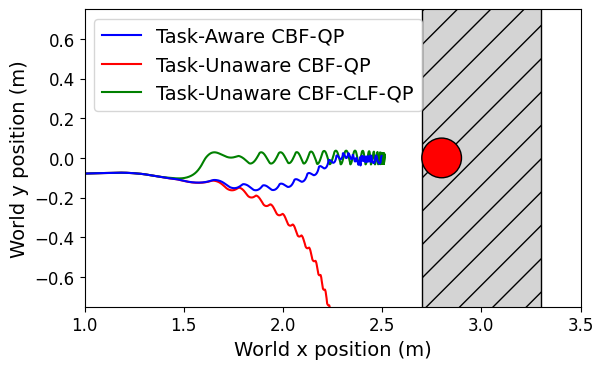

In [147]:
# Trajectory plots for obstacle

data_threshold = 10000

composite_3 = np.load("./composite_pos_3.npy")
separated_1 = np.load("./separated_1.npy")
pure = np.load("./pure_trial_1.npy")

fig, ax = plt.subplots()

rect = Rectangle((2.7, -1.8), width=0.6, height=3.6, 
                 edgecolor='black', facecolor=(0.83, 0.83, 0.83), hatch="/")
circle_target = Circle((2.8, 0.0), radius=0.1, edgecolor="black", facecolor="red")
circle_composite = Circle((composite_3[data_threshold-1, :2]), radius=0.4, facecolor=(0.5,0.5,1.0,0.25))
circle_separate_1 = Circle((separated_1[data_threshold-1,:2]), radius=0.4, facecolor=(0, 1, 0, 0.25))
ax.add_patch(rect)
ax.add_patch(circle_target)
#ax.add_patch(circle_composite)
#ax.add_patch(circle_separate_1)

ax.plot(pure[:data_threshold,0], pure[:data_threshold,1], color="r", label="Task-Unaware CBF-QP")
ax.plot(separated_1[:data_threshold,0], separated_1[:data_threshold,1], color="g", label="Task-Unaware CBF-CLF-QP")
ax.plot(composite_3[:data_threshold,0], composite_3[:data_threshold,1], color="b", label="Task-Aware CBF-QP")

ax.set_xlim(1.0, 3.5)
ax.set_ylim(-0.75, 0.75)
ax.set_aspect('equal')
plt.grid(False)
#plt.title('Robot Trajectory Approaching Target Under Forward Command')
plt.xlabel("World x position (m)")
plt.ylabel("World y position (m)")

handles, labels = ax.get_legend_handles_labels()
order = [2, 0, 1]
ax.legend([handles[i] for i in order], [labels[i] for i in order])
plt.show()

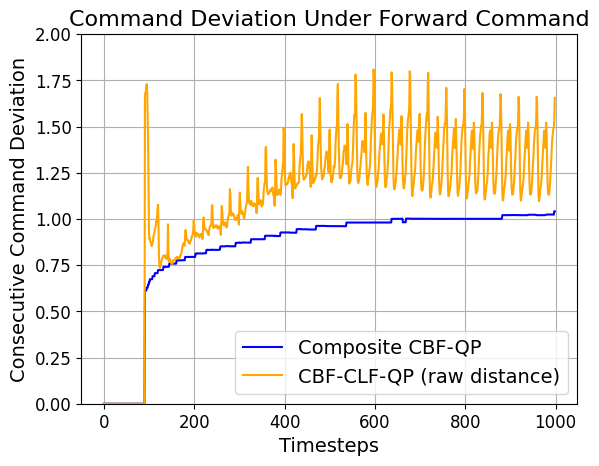

In [148]:
# Consecutive command error (squared error)

composite_cmds = np.load("./composite_cmds_3.npy")
separated_cmds = np.load("./separated_cmds.npy")

def command_change(cmd_array):
    change = []
    for i in range(np.size(cmd_array,axis=0)):
        if i != 0:
            original_cmd = [1.0, 0.0, 0.0]
            prev_cmd = cmd_array[i-1]
            curr_cmd = cmd_array[i]
            change.append(np.sum((curr_cmd - original_cmd)**2))
        else:
            change.append(0)
    return np.array(change)

fig, ax = plt.subplots()

ax.plot(range(np.size(composite_cmds,axis=0)), command_change(composite_cmds), color="b", label="Composite CBF-QP")
ax.plot(range(np.size(separated_cmds,axis=0)), command_change(separated_cmds), color=(1.0,0.65,0), label="CBF-CLF-QP (raw distance)")
ax.set_ylim(0, 2.0)
plt.title('Command Deviation Under Forward Command')
plt.xlabel("Timesteps")
plt.ylabel("Consecutive Command Deviation")
plt.grid(True)
plt.legend()
plt.show()


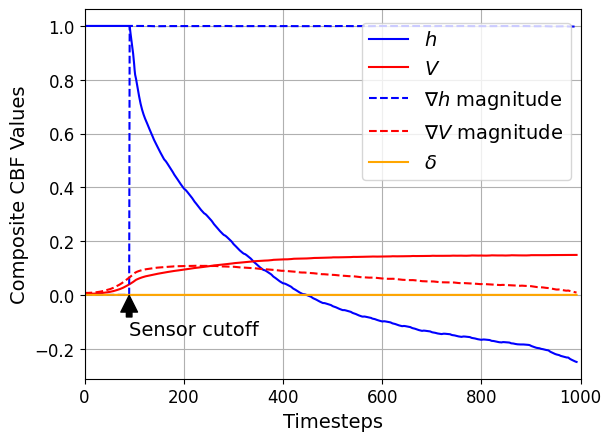

In [149]:
# CBF values
# [cbf.h_static_obs, cbf.h_workspace, np.linalg.norm(cbf.grad_h_static_obs), np.linalg.norm(cbf.grad_h_workspace), cbf.moving_slack]
composite_values = np.load("./composite_values_3.npy")[0]
fig, ax = plt.subplots()

h_static = composite_values[:, 0]
h_workspace = composite_values[:, 1]
h_grad_static = composite_values[:, 2]
h_grad_workspace = composite_values[:, 3]
h_slack = composite_values[:, 4]

ax.plot(range(np.size(composite_values,axis=0)), h_static, color="b", label=r'$h$')
ax.plot(range(np.size(composite_values,axis=0)), h_workspace, color="r", label=r'$V$')
ax.plot(range(np.size(composite_values,axis=0)), h_grad_static, color="b", label=r'$\nabla h$ magnitude', ls="--")
ax.plot(range(np.size(composite_values,axis=0)), h_grad_workspace, color="r", label=r'$\nabla V$ magnitude', ls="--")
ax.plot(range(np.size(composite_values,axis=0)), h_slack, color=(1.0,0.65,0), label=r'$\delta$')
#plt.title('Composite CBF Values Under Forward Command')
plt.xlabel("Timesteps")
plt.ylabel("Composite CBF Values")
ax.set_xlim(0, 1000)
plt.grid(True)
plt.legend(loc='right', bbox_to_anchor=(1.0, 0.75))
# plt.text(, -0.1, 'sensor cutoff', fontsize=12)
plt.annotate('Sensor cutoff', xy=(90, 0), xytext=(90, -0.15),
             arrowprops=dict(facecolor='black', shrink=0.02))
plt.show()

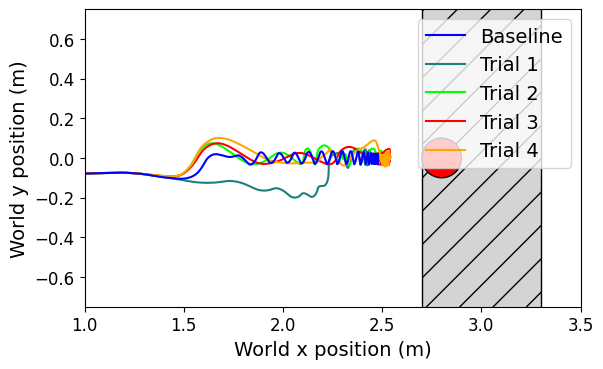

In [150]:
# Trajectory plots for tuning alpha and gamma for separate CBF_CLF

data_threshold = 10000

# Load data
separated_1 = np.load("./separated_pos_1.npy")
separated_2 = np.load("./separated_pos_2.npy")
separated_4 = np.load("./separated_pos_4.npy")
separated_5 = np.load("./separated_pos_5.npy")
separated_6 = np.load("./separated_pos_6.npy")

fig, ax = plt.subplots()

rect = Rectangle((2.7, -1.8), width=0.6, height=3.6, 
                 edgecolor='black', facecolor=(0.83, 0.83, 0.83), hatch="/")
circle_target = Circle((2.8, 0.0), radius=0.1, edgecolor="black", facecolor="red")
circle_separated_1 = Circle((separated_1[data_threshold-1,:2]), radius=0.4, facecolor=(0,0,1.0,0.15))
ax.add_patch(rect)
ax.add_patch(circle_target)
#ax.add_patch(circle_separated_1)

ax.plot(separated_2[:data_threshold,0], separated_2[:data_threshold,1], color=(0.1,0.5,0.5), label="Trial 1")
ax.plot(separated_4[:data_threshold,0], separated_4[:data_threshold,1], color=(0,1.0,0), label="Trial 2")
ax.plot(separated_5[:data_threshold,0], separated_5[:data_threshold,1], color=(1.0,0,0), label="Trial 3")
ax.plot(separated_6[:data_threshold,0], separated_6[:data_threshold,1], color=(1,0.65,0), label="Trial 4")
ax.plot(separated_1[:data_threshold,0], separated_1[:data_threshold,1], color=(0,0,1.0), label="Baseline")

handles, labels = ax.get_legend_handles_labels()
order = [4, 0, 1, 2, 3]
ax.legend([handles[i] for i in order], [labels[i] for i in order])

ax.set_xlim(1.0, 3.5)
ax.set_ylim(-0.75, 0.75)
ax.set_aspect('equal')
plt.grid(False)
#plt.title('Separate CBF-CLF constraints under different tuning parameters')
plt.xlabel("World x position (m)")
plt.ylabel("World y position (m)")
plt.show()

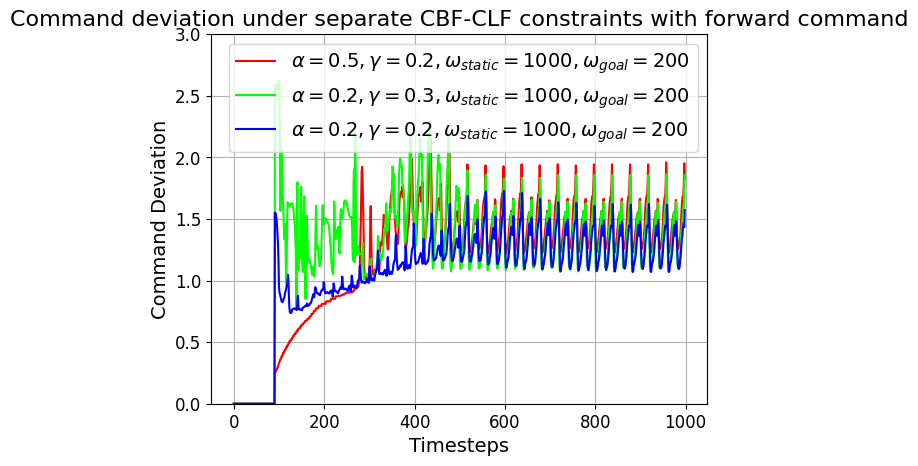

Consecutive command deviation 2
0.00960850850850851
0.013335586058858115
Consecutive command deviation 4
0.024653653653653653
0.11530158585147053
Consecutive command deviation 1
0.008777077077077077
0.049500808024315376


In [151]:
# Consecutive command error for tuning alpha and gamma for separate CBF_CLF

# Load data
separated_cmds_1 = np.load("./separated_cmds_1.npy")
separated_cmds_2 = np.load("./separated_cmds_2.npy")
separated_cmds_4 = np.load("./separated_cmds_4.npy")

def command_change(cmd_array):
    change = []
    for i in range(np.size(cmd_array,axis=0)):
        if i != 0:
            original_cmd = [1.0, 0.0, 0.0]
            prev_cmd = cmd_array[i-1]
            curr_cmd = cmd_array[i]
            change.append(np.sum((curr_cmd - original_cmd)**2))
        else:
            change.append(0)
    return np.array(change)

fig, ax = plt.subplots()

ax.plot(range(np.size(separated_cmds_2,axis=0)), command_change(separated_cmds_2), color=(1.0,0,0), label=r"$\alpha=0.5,\gamma=0.2, \omega_{static}=1000, \omega_{goal}=200$")
ax.plot(range(np.size(separated_cmds_4,axis=0)), command_change(separated_cmds_4), color=(0,1,0), label=r"$\alpha=0.2,\gamma=0.3, \omega_{static}=1000, \omega_{goal}=200$")
ax.plot(range(np.size(separated_cmds_1,axis=0)), command_change(separated_cmds_1), color=(0,0,1.0), label=r"$\alpha=0.2,\gamma=0.2, \omega_{static}=1000, \omega_{goal}=200$")
ax.set_ylim(0, 3.0)
plt.title('Command deviation under separate CBF-CLF constraints with forward command')
plt.xlabel("Timesteps")
plt.ylabel("Command Deviation")
plt.grid(True)
plt.legend()
plt.show()

def consecutive_change(cmd_array):
    change = []
    for i in range(np.size(cmd_array,axis=0)):
        if i != 0:
            prev_cmd = cmd_array[i-1]
            curr_cmd = cmd_array[i]
            change.append(np.sum((curr_cmd - prev_cmd)**2))
        else:
            change.append(0)
    return np.array(change)

separated_change_2 = consecutive_change(separated_cmds_2)
print("Consecutive command deviation 2")
print(np.mean(separated_change_2))
print(np.std(separated_change_2))
separated_change_4 = consecutive_change(separated_cmds_4)
print("Consecutive command deviation 4")
print(np.mean(separated_change_4))
print(np.std(separated_change_4))
separated_change_1 = consecutive_change(separated_cmds_1)
print("Consecutive command deviation 1")
print(np.mean(separated_change_1))
print(np.std(separated_change_1))

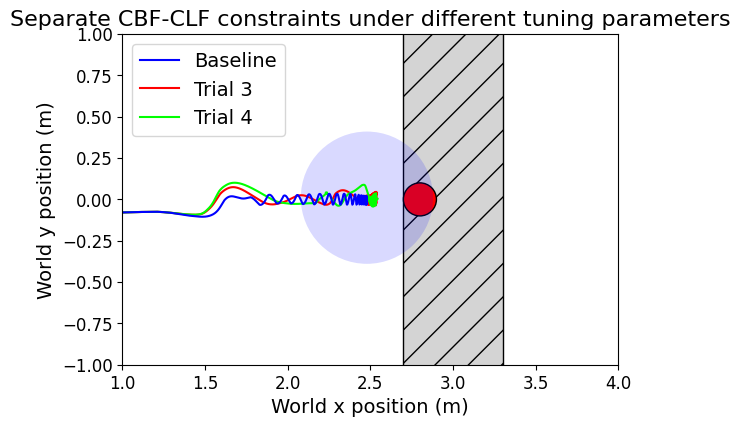

In [152]:
# Trajectory plots for tuning slack in separate CBF-CLF

data_threshold = 10000

# Load data
separated_1 = np.load("./separated_pos_1.npy")
separated_5 = np.load("./separated_pos_5.npy")
separated_6 = np.load("./separated_pos_6.npy")

fig, ax = plt.subplots()

rect = Rectangle((2.7, -1.8), width=0.6, height=3.6, 
                 edgecolor='black', facecolor=(0.83, 0.83, 0.83), hatch="/")
circle_target = Circle((2.8, 0.0), radius=0.1, edgecolor="black", facecolor="red")
circle_separated_1 = Circle((separated_1[data_threshold-1,:2]), radius=0.4, facecolor=(0,0,1.0,0.15))
ax.add_patch(rect)
ax.add_patch(circle_target)
ax.add_patch(circle_separated_1)

ax.plot(separated_5[:data_threshold,0], separated_5[:data_threshold,1], color=(1.0,0,0), label="Trial 3")
ax.plot(separated_6[:data_threshold,0], separated_6[:data_threshold,1], color=(0,1.0,0), label="Trial 4")
ax.plot(separated_1[:data_threshold,0], separated_1[:data_threshold,1], color=(0,0,1.0), label="Baseline")

handles, labels = ax.get_legend_handles_labels()
order = [2, 0, 1]
ax.legend([handles[i] for i in order], [labels[i] for i in order])

ax.set_xlim(1, 4)
ax.set_ylim(-1, 1)
ax.set_aspect('equal')
plt.grid(False)
plt.title('Separate CBF-CLF constraints under different tuning parameters')
plt.xlabel("World x position (m)")
plt.ylabel("World y position (m)")
plt.show()

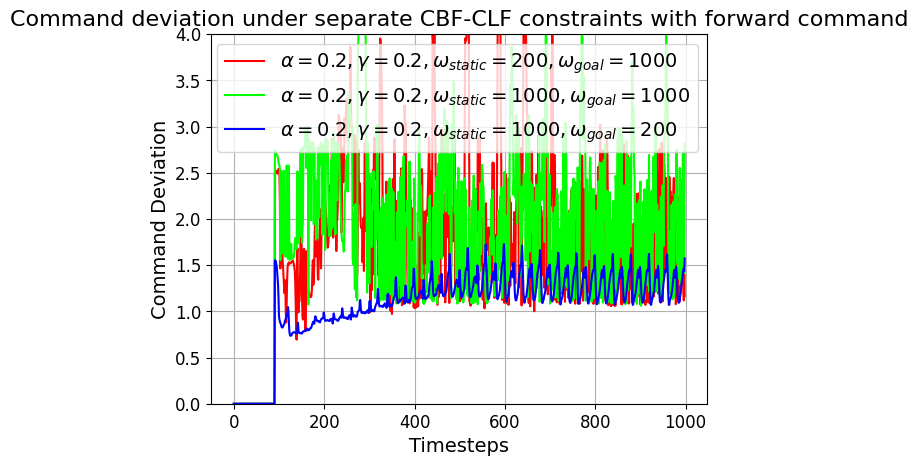

Consecutive command deviation 5
0.6060604604604605
1.0652043157077382
Consecutive command deviation 6
0.8224060060060059
1.2530036366896633
Consecutive command deviation 1
0.008777077077077077
0.049500808024315376


In [153]:
# Consecutive command error for tuning slack weight for separate CBF_CLF

# Load data
separated_cmds_1 = np.load("./separated_cmds_1.npy")
separated_cmds_5 = np.load("./separated_cmds_5.npy")
separated_cmds_6 = np.load("./separated_cmds_6.npy")

def command_change(cmd_array):
    change = []
    for i in range(np.size(cmd_array,axis=0)):
        if i != 0:
            original_cmd = [1.0, 0.0, 0.0]
            curr_cmd = cmd_array[i]
            change.append(np.sum((curr_cmd - original_cmd)**2))
        else:
            change.append(0)
    return np.array(change)

fig, ax = plt.subplots()

ax.plot(range(np.size(separated_cmds_5,axis=0)), command_change(separated_cmds_5), color=(1.0,0,0), label=r"$\alpha=0.2,\gamma=0.2, \omega_{static}=200, \omega_{goal}=1000$")
ax.plot(range(np.size(separated_cmds_6,axis=0)), command_change(separated_cmds_6), color=(0,1.0,0), label=r"$\alpha=0.2,\gamma=0.2, \omega_{static}=1000, \omega_{goal}=1000$")
ax.plot(range(np.size(separated_cmds_1,axis=0)), command_change(separated_cmds_1), color=(0,0,1.0), label=r"$\alpha=0.2,\gamma=0.2, \omega_{static}=1000, \omega_{goal}=200$")
ax.set_ylim(0, 4.0)
plt.title('Command deviation under separate CBF-CLF constraints with forward command')
plt.xlabel("Timesteps")
plt.ylabel("Command Deviation")
plt.grid(True)
plt.legend()
plt.show()

def consecutive_change(cmd_array):
    change = []
    for i in range(np.size(cmd_array,axis=0)):
        if i != 0:
            prev_cmd = cmd_array[i-1]
            curr_cmd = cmd_array[i]
            change.append(np.sum((curr_cmd - prev_cmd)**2))
        else:
            change.append(0)
    return np.array(change)

separated_change_5 = consecutive_change(separated_cmds_5)
print("Consecutive command deviation 5")
print(np.mean(separated_change_5))
print(np.std(separated_change_5))
separated_change_6 = consecutive_change(separated_cmds_6)
print("Consecutive command deviation 6")
print(np.mean(separated_change_6))
print(np.std(separated_change_6))
separated_change_1 = consecutive_change(separated_cmds_1)
print("Consecutive command deviation 1")
print(np.mean(separated_change_1))
print(np.std(separated_change_1))



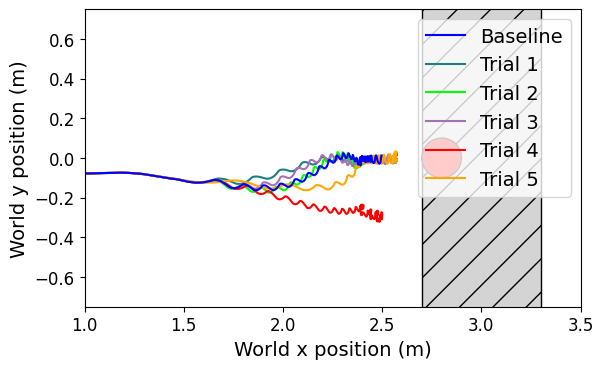

In [154]:
# Trajectory plots for tuning slack in composite CBF

data_threshold = 10000

# Load data
composite_1 = np.load("./composite_pos_1.npy")
composite_2 = np.load("./composite_pos_2.npy")
composite_3 = np.load("./composite_pos_3.npy")
composite_4 = np.load("./composite_pos_4.npy")
composite_5 = np.load("./composite_pos_5.npy")
composite_6 = np.load("./composite_pos_6.npy")
composite_7 = np.load("./composite_pos_7.npy")

fig, ax = plt.subplots()

rect = Rectangle((2.7, -1.8), width=0.6, height=3.6, 
                 edgecolor='black', facecolor=(0.83, 0.83, 0.83), hatch="/")
circle_target = Circle((2.8, 0.0), radius=0.1, edgecolor="black", facecolor="red")
circle_separated_1 = Circle((composite_3[data_threshold-1,:2]), radius=0.4, facecolor=(0,0,1.0,0.15))
ax.add_patch(rect)
ax.add_patch(circle_target)
#ax.add_patch(circle_separated_1)

ax.plot(composite_4[:data_threshold,0], composite_4[:data_threshold,1], color=(0.1,0.5,0.5), label="Trial 1")
ax.plot(composite_7[:data_threshold,0], composite_7[:data_threshold,1], color=(0,1.0,0), label="Trial 2")
ax.plot(composite_5[:data_threshold,0], composite_5[:data_threshold,1], color=(0.65,0.44,0.71), label="Trial 3")
ax.plot(composite_2[:data_threshold,0], composite_2[:data_threshold,1], color=(1.0,0,0), label="Trial 4")
ax.plot(composite_6[:data_threshold,0], composite_6[:data_threshold,1], color=(1,0.65,0), label="Trial 5")
ax.plot(composite_3[:data_threshold,0], composite_3[:data_threshold,1], color=(0,0.0,1.0), label="Baseline")

handles, labels = ax.get_legend_handles_labels()
order = [5, 0, 1, 2, 3, 4]
ax.legend([handles[i] for i in order], [labels[i] for i in order])

ax.set_xlim(1.0, 3.5)
ax.set_ylim(-0.75, 0.75)
ax.set_aspect('equal')
plt.grid(False)
#plt.title('Composite CBF constraints under different tuning parameters')
plt.xlabel("World x position (m)")
plt.ylabel("World y position (m)")
plt.show()

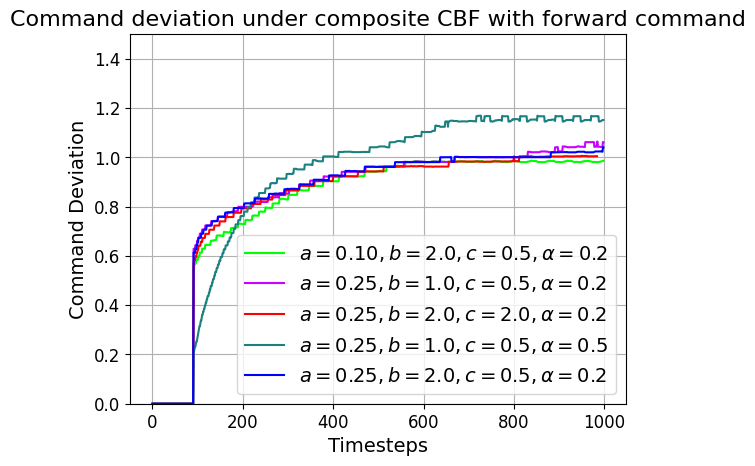

Baseline - Consecutive command deviation 3
0.0006333333333333334
0.019406347062399618
Trial 1 - Consecutive command deviation 4
0.0006193193193193194
0.017542480889911494
Trial 2 - Consecutive command deviation 7
0.0006452452452452454
0.019893428145955974
Trial 3 - Consecutive command deviation 5
0.0006643643643643644
0.019892896186580314
Trial 4 - Consecutive command deviation 2
0.0005848730964467004
0.018040747016204103
Trial 5 - Consecutive command deviation 6
0.00025965965965965955
0.006456364993803981


In [155]:
# Consecutive command error for tuning slack weight for composite CBF

# Load data
composite_cmds_2 = np.load("./composite_cmds_2.npy")
composite_cmds_3 = np.load("./composite_cmds_3.npy")
composite_cmds_4 = np.load("./composite_cmds_4.npy")
composite_cmds_5 = np.load("./composite_cmds_5.npy")
composite_cmds_6 = np.load("./composite_cmds_6.npy")
composite_cmds_7 = np.load("./composite_cmds_7.npy")


def command_change(cmd_array):
    change = []
    for i in range(np.size(cmd_array,axis=0)):
        if i != 0:
            original_cmd = [1.0, 0.0, 0.0]
            prev_cmd = cmd_array[i-1]
            curr_cmd = cmd_array[i]
            change.append(np.sum((curr_cmd - original_cmd)**2))
        else:
            change.append(0)
    return np.array(change)

fig, ax = plt.subplots()

ax.plot(range(np.size(composite_cmds_4,axis=0)), command_change(composite_cmds_4), color=(0,1.0,0), label=r"$a=0.10, b=2.0, c=0.5, \alpha=0.2$")
ax.plot(range(np.size(composite_cmds_5,axis=0)), command_change(composite_cmds_5), color=(0.8,0.0,1.0), label=r"$a=0.25, b=1.0, c=0.5, \alpha=0.2$")
ax.plot(range(np.size(composite_cmds_2,axis=0)), command_change(composite_cmds_2), color=(1.0,0,0), label=r"$a=0.25, b=2.0, c=2.0, \alpha=0.2$")
ax.plot(range(np.size(composite_cmds_6,axis=0)), command_change(composite_cmds_6), color=(0.1,0.5,0.5), label=r"$a=0.25, b=1.0, c=0.5, \alpha=0.5$")
ax.plot(range(np.size(composite_cmds_3,axis=0)), command_change(composite_cmds_3), color=(0,0.0,1.0), label=r"$a=0.25, b=2.0, c=0.5, \alpha=0.2$")
ax.set_ylim(0, 1.5)
plt.title('Command deviation under composite CBF with forward command')
plt.xlabel("Timesteps")
plt.ylabel("Command Deviation")
plt.grid(True)
plt.legend()
plt.show()

def consecutive_change(cmd_array):
    change = []
    for i in range(np.size(cmd_array,axis=0)):
        if i != 0:
            prev_cmd = cmd_array[i-1]
            curr_cmd = cmd_array[i]
            change.append(np.sum((curr_cmd - prev_cmd)**2))
        else:
            change.append(0)
    return np.array(change)

composite_change_3 = consecutive_change(composite_cmds_3)
print("Baseline - Consecutive command deviation 3")
print(np.mean(composite_change_3))
print(np.std(composite_change_3))
composite_change_4 = consecutive_change(composite_cmds_4)
print("Trial 1 - Consecutive command deviation 4")
print(np.mean(composite_change_4))
print(np.std(composite_change_4))
composite_change_7 = consecutive_change(composite_cmds_7)
print("Trial 2 - Consecutive command deviation 7")
print(np.mean(composite_change_7))
print(np.std(composite_change_7))
composite_change_5 = consecutive_change(composite_cmds_5)
print("Trial 3 - Consecutive command deviation 5")
print(np.mean(composite_change_5))
print(np.std(composite_change_5))
composite_change_2 = consecutive_change(composite_cmds_2)
print("Trial 4 - Consecutive command deviation 2")
print(np.mean(composite_change_2))
print(np.std(composite_change_2))
composite_change_6 = consecutive_change(composite_cmds_6)
print("Trial 5 - Consecutive command deviation 6")
print(np.mean(composite_change_6))
print(np.std(composite_change_6))


### Scenario 2: Pure Obstacle

(9452, 3)


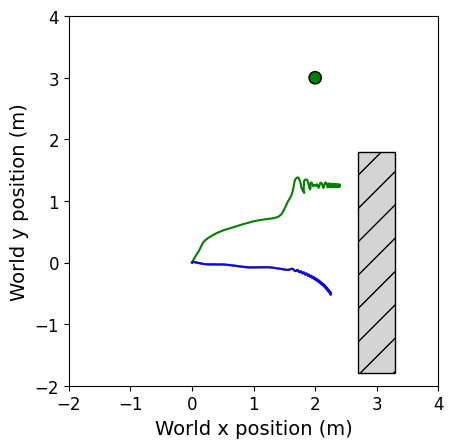

In [156]:
# Trajectory plots for obstacle

composite = np.load("./composite_CBF/composite_pos_scenario2.npy")
separated = np.load("./CBF-CLF/separated_pos_scenario2.npy")
base = np.load("./base_CBF/base_pos_scenario2.npy")
switching = np.load("./switching_CBF/switching_pos_scenario2.npy")


print(composite.shape)

fig, ax = plt.subplots()

rect = Rectangle((2.7, -1.8), width=0.6, height=3.6, 
                 edgecolor='black', facecolor=(0.83, 0.83, 0.83), hatch="/")
circle_target = Circle((2, 3), radius=0.1, edgecolor="black", facecolor="green")
ax.add_patch(rect)
ax.add_patch(circle_target)

ax.plot(base[:,0], base[:,1], color="r", label="CBF-QP")
ax.plot(separated[:,0], separated[:,1], color="g", label="CBF-CLF-QP")
ax.plot(switching[:,0], switching[:,1], color="y", label="Switching CBF-QP")
ax.plot(composite[:,0], composite[:,1], color="b", label="Task-Aware CBF-QP")
ax.set_xlim(-2, 4)
ax.set_ylim(-2, 4)
ax.set_aspect('equal')
plt.grid(False)
handles, labels = ax.get_legend_handles_labels()
order = [2, 0, 1]
plt.xlabel("World x position (m)")
plt.ylabel("World y position (m)")
plt.show()

### Scenario 3: Moving Obstacle

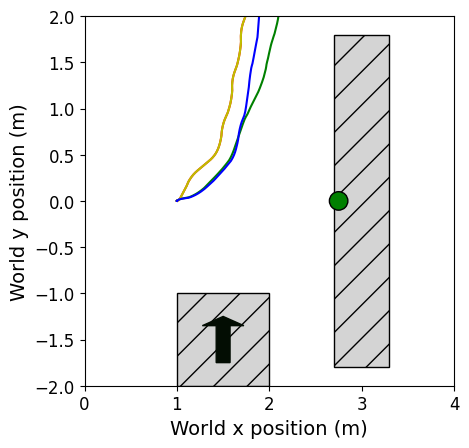

In [157]:
# Trajectory plots for obstacle

data_threshold = 2000

composite = np.load("./composite_CBF/composite_pos_scenario3.npy")
separated = np.load("./CBF-CLF/separated_pos_scenario3.npy")
base = np.load("./base_CBF/base_pos_scenario3.npy")
switching = np.load("./switching_CBF/switching_pos_scenario3.npy")

fig, ax = plt.subplots()

rect_obs = Rectangle((2.7, -1.8), width=0.6, height=3.6, 
                 edgecolor='black', facecolor=(0.83, 0.83, 0.83), hatch="/")
rect_moving = Rectangle((1, -2), width=1, height=1, 
                 edgecolor='black', facecolor=(0.83, 0.83, 0.83), hatch="/")
circle_target = Circle((2.75, 0), radius=0.1, edgecolor="black", facecolor="green")
circle_composite = Circle((composite[data_threshold-1, :2]), radius=0.05, facecolor="b")
arrow = Arrow(1.5, -1.75, 0, 0.5, width=0.75, color=(0.01, 0.05, 0.01))
ax.add_patch(rect_obs)
ax.add_patch(rect_moving)
ax.add_patch(circle_target)
ax.add_patch(arrow)

ax.plot(base[:,0], base[:,1], color="r", label="CBF-QP")
ax.plot(separated[:,0], separated[:,1], color="g", label="CBF-CLF-QP")
ax.plot(switching[:,0], switching[:,1], color="y", label="Switching CBF-QP")
ax.plot(composite[:,0], composite[:,1], color="b", label="Task-Aware CBF-QP")
ax.set_xlim(0, 4)
ax.set_ylim(-2, 2)
ax.set_aspect('equal')
plt.grid(False)
plt.xlabel("World x position (m)")
plt.ylabel("World y position (m)")
plt.show()

### Contact Checking

In [158]:
contact_2 = np.load("./composite_col_2.npy")
contact_3 = np.load("./composite_col_3.npy")
contact_4 = np.load("./composite_col_4.npy")
contact_5 = np.load("./composite_col_5.npy")
contact_6 = np.load("./composite_col_6.npy")
contact_7 = np.load("./composite_col_7.npy")



print(contact_2)
print(contact_3)
print(max(contact_4))
print(max(contact_5))
print(max(contact_6))
print(contact_7)

[]
[]
272.4382231258059
98.06503094424855
194.26540712223428
[]


In [159]:
separated_1 = np.load("./separated_col_1.npy")
separated_2 = np.load("./separated_col_2.npy")
separated_3 = np.load("./separated_col_3.npy")
separated_4 = np.load("./separated_col_4.npy")
separated_5 = np.load("./separated_col_5.npy")
separated_6 = np.load("./separated_col_6.npy")


print(separated_1)
print(separated_2)
print(separated_3)
print(separated_4)
print(max(separated_5))
print(max(separated_6))

[]
[]
[]
[]
221.89950680151622
255.88395119930814


## Safety Map

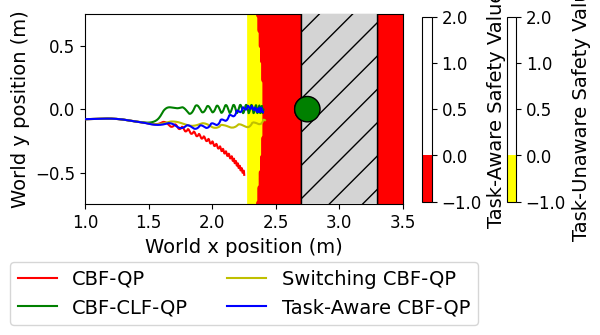

In [160]:
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle, Circle, Arrow

# Define thresholds and corresponding colors for task-unaware
bounds2 = [-1, 0, 0.5, 1, 2.0]
colors2 = ['yellow', 'none', 'none', 'none']
cmap2 = mcolors.ListedColormap(colors2)
norm2 = mcolors.BoundaryNorm(bounds2, cmap2.N)
# Define thresholds and corresponding colors for task-aware
bounds = [-1, 0, 0.5, 1, 2.0]
colors = ['red', 'none', 'none', 'none']
cmap = mcolors.ListedColormap(colors)
norm = mcolors.BoundaryNorm(bounds, cmap.N)

safety_map_task = np.load("./safety_map_comp.npy")
safety_map_taskless = np.load("./safety_map_obs.npy")

fig, ax = plt.subplots()
data_threshold = 10000

composite = np.load("./composite_CBF/composite_pos_scenario1.npy")
separated = np.load("./CBF-CLF/separated_pos_scenario1.npy")
base = np.load("./base_CBF/base_pos_scenario1.npy")
switching = np.load("./switching_CBF/switching_pos.npy")

rect = Rectangle((2.7, -1.8), width=0.6, height=3.6, 
                 edgecolor='black', facecolor=(0.83, 0.83, 0.83), hatch="/", zorder=3)
circle_target = Circle((2.75, 0.0), radius=0.1, edgecolor="black", facecolor="green", zorder=3)
ax.add_patch(rect)
ax.add_patch(circle_target)

ax.plot(base[:,0], base[:,1], color="r", label="CBF-QP", zorder=3)
ax.plot(separated[:,0], separated[:,1], color="g", label="CBF-CLF-QP",zorder=3)
ax.plot(switching[:,0], switching[:,1], color="y", label="Switching CBF-QP", zorder=3)
ax.plot(composite[:,0], composite[:,1], color="b", label="Task-Aware CBF-QP", zorder=3)

task_safety_plot = ax.scatter(
    safety_map_task[:, 0],  # x
    safety_map_task[:, 1],  # y
    c=safety_map_task[:, 2],  # h value = color
    cmap=cmap,
    norm=norm,
    s=10,  # dot size
    zorder=2
)

taskless_safety_plot = ax.scatter(
    safety_map_taskless[:, 0],  # x
    safety_map_taskless[:, 1],  # y
    c=safety_map_taskless[:, 2],  # h value = color
    cmap=cmap2,
    norm=norm2,
    s=10, # dot size
    zorder=1
)

cbar_taskless = fig.colorbar(taskless_safety_plot, ax=ax, label='Task-Unaware Safety Value', shrink=0.5)
cbar_task = fig.colorbar(task_safety_plot, ax=ax, label='Task-Aware Safety Value', shrink=0.5)
ax.set_xlim(1.0, 3.5)
ax.set_ylim(-0.75, 0.75)
ax.set_xlabel('World x position (m)')
ax.set_ylabel('World y position (m)')
ax.add_patch(rect)
ax.add_patch(circle_target)
ax.set_aspect('equal')
handles, labels = ax.get_legend_handles_labels()
order = [0,1,2,3]
ax.legend([handles[i] for i in order], [labels[i] for i in order],
          loc='upper center',
          bbox_to_anchor=(0.5, -0.25),
          ncol=2)  # number of columns)
plt.show()

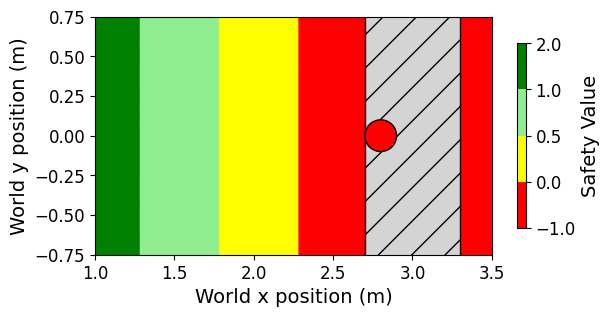

In [161]:
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np

# Define thresholds and corresponding colors
bounds = [-1, 0, 0.5, 1, 2.0]  # your thresholds
colors = ['red', 'yellow', 'lightgreen', 'green']

cmap = mcolors.ListedColormap(colors)
norm = mcolors.BoundaryNorm(bounds, cmap.N)

safety_map = np.load("./safety_map_obs.npy")

fig, ax = plt.subplots()
circle_target = Circle((2.8, 0.0), radius=0.1, edgecolor="black", facecolor="red")
rect = Rectangle((2.7, -1.8), width=0.6, height=3.6, 
                 edgecolor='black', facecolor=(0.83, 0.83, 0.83), hatch="/")

safety_plot = ax.scatter(
    safety_map[:, 0],  # x
    safety_map[:, 1],  # y
    c=safety_map[:, 2],  # h value = color
    cmap=cmap,
    norm=norm,
    s=10  # dot size
)
cbar = fig.colorbar(safety_plot, ax=ax, label='Safety Value', shrink=0.5)
ax.set_xlim(1.0, 3.5)
ax.set_ylim(-0.75, 0.75)
ax.set_xlabel('World x position (m)')
ax.set_ylabel('World y position (m)')
ax.add_patch(rect)
ax.add_patch(circle_target)
#plt.title("CBF-CLF Safety Map")
ax.set_aspect('equal')
plt.show()

# Checking Policy Tracking

In [162]:
import numpy as np
forward_vel = np.load("./forward_benchmark.npy")
side_vel = np.load("./side_benchmark.npy")
rotate_vel = np.load("./rotating_benchmark.npy")

def tracking_change(actual_arr, nominal):
    change = []
    for i in range(np.size(actual_arr,axis=0)):
            curr_cmd = actual_arr[i]
            change.append(np.linalg.norm((curr_cmd - nominal)))
    return np.array(change)

def tracking_change(actual_arr, nominal):
    change = []
    for i in range(np.size(actual_arr, axis=0)):
        curr_cmd = actual_arr[i]
        change.append(np.sqrt(np.sum((curr_cmd - nominal)**2)))  # Euclidean distance
    return np.array(change)

forward_change = tracking_change(forward_vel, [1,0,0])
forward_mean = np.mean(forward_change)
side_change = tracking_change(side_vel, [0,1,0])
side_mean = np.mean(side_change)
rotate_change = tracking_change(rotate_vel, [0,0,1])
rotate_mean = np.mean(rotate_change)

print(forward_mean)
print(side_mean)
print(rotate_mean)

0.19345081955216165
0.3682410549331274
0.1400249235984339


## Monte Carlo Convergence

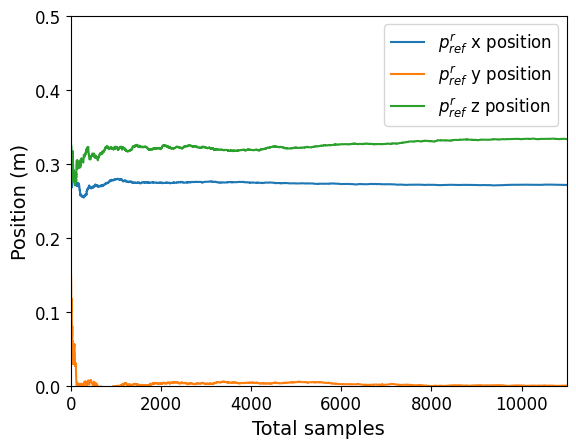

In [163]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.size": 14,          # base size
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
})

weighted = np.load("../pointcloud/workspace_weighted_point.npy")

rows = np.arange(len(weighted))

fig, ax = plt.subplots()
ax.plot(rows, weighted[:, 0], label=r'$p^r_{ref}$ x position')
ax.plot(rows, weighted[:, 1], label=r'$p^r_{ref}$ y position')
ax.plot(rows, weighted[:, 2], label=r'$p^r_{ref}$ z position')
ax.set_xlabel('Total samples')
ax.set_ylabel('Position (m)')
ax.set_xlim(0.0, 11000)
ax.set_ylim(0.0, 0.5)
ax.legend()
plt.show()

## Parameter Recording

In [16]:
import numpy as np

# Path length
def path_length(points):
    diffs = np.diff(points, axis=0)      # (N-1, d)
    segment_lengths = np.linalg.norm(diffs, axis=1)
    return np.sum(segment_lengths)

# Time to target
def path_time(points):
    time = points.shape[0] * 0.002
    return time

# Consecutive control deviation
def consecutive_change(cmd_array):
    change = []
    for i in range(np.size(cmd_array,axis=0)):
        if i != 0:
            prev_cmd = cmd_array[i-1]
            curr_cmd = cmd_array[i]
            change.append(np.sum((curr_cmd - prev_cmd)**2))
        else:
            change.append(0)
    change = np.array(change)
    return np.mean(change)

def val_extraction(vals):
    # Penetration depth
    penetration = np.max(-np.min(vals[0:,0]), 0)
    # Slack activation
    slack = np.max(vals[0,0:,-2])
    # Terminal velocity
    terminal_vel = vals[0,-1,-1]

    return [penetration, slack, terminal_vel]

def parameter_curve(points, cmds, vals):
    # print("Time to Target:", path_time(points))
    # print("Path Length:", path_length(points))
    # print("Consecutive Control Deviation", consecutive_change(cmds))
    # print("Penetration Depth:", val_extraction(vals)[0])
    # print("Max Slack:", val_extraction(vals)[1])
    # print("Terminal Velocity:", val_extraction(vals)[2])
    return [path_time(points), path_length(points), consecutive_change(cmds), 
            val_extraction(vals)[0], val_extraction(vals)[1], val_extraction(vals)[2]]

In [17]:
# Varying a

points_02 = np.load("composite_pos_baseline.npy")
cmds_02 = np.load("composite_cmds_baseline.npy")
vals_02 = np.load("composite_vals_baseline.npy")
points_04 = np.load("./varying_a/composite_pos_0.4.npy")
cmds_04 = np.load("./varying_a/composite_cmds_0.4.npy")
vals_04 = np.load("./varying_a/composite_vals_0.4.npy")
points_06 = np.load("./varying_a/composite_pos_0.6.npy")
cmds_06 = np.load("./varying_a/composite_cmds_0.6.npy")
vals_06 = np.load("./varying_a/composite_vals_0.6.npy")
points_08 = np.load("./varying_a/composite_pos_0.8.npy")
cmds_08 = np.load("./varying_a/composite_cmds_0.8.npy")
vals_08 = np.load("./varying_a/composite_vals_0.8.npy")
points_10 = np.load("./varying_a/composite_pos_1.0.npy")
cmds_10 = np.load("./varying_a/composite_cmds_1.0.npy")
vals_10 = np.load("./varying_a/composite_vals_1.0.npy")

parameters_a = np.array(parameter_curve(points_02, cmds_02, vals_02))
parameters_a = np.vstack((parameters_a, parameter_curve(points_04, cmds_04, vals_04)))
parameters_a = np.vstack((parameters_a, parameter_curve(points_06, cmds_06, vals_06)))
parameters_a = np.vstack((parameters_a, parameter_curve(points_08, cmds_08, vals_08)))
parameters_a = np.vstack((parameters_a, parameter_curve(points_10, cmds_10, vals_10)))
print(parameters_a)

[[ 1.33020000e+01  3.11934845e+00  9.14900015e-05 -0.00000000e+00
   1.02694618e-06  4.63143946e-02]
 [ 9.60800000e+00  2.80474553e+00  1.21294754e-04 -0.00000000e+00
   1.07052707e-06  1.34291980e-01]
 [ 7.57800000e+00  2.69132462e+00  1.42544207e-04 -0.00000000e+00
   1.13101677e-06  1.47989139e-01]
 [ 6.30000000e+00  2.63752366e+00  1.59746032e-04 -0.00000000e+00
   1.19491513e-06  1.31362343e-01]
 [ 5.29400000e+00  2.60263767e+00  1.77106158e-04 -0.00000000e+00
   1.26091066e-06  9.28737350e-02]]


In [18]:
# Varying b

points_b05 = np.load("./varying_b/composite_pos_b0.5.npy")
cmds_b05 = np.load("./varying_b/composite_cmds_b0.5.npy")
vals_b05 = np.load("./varying_b/composite_vals_b0.5.npy")
points_b10 = np.load("./varying_b/composite_pos_b1.0.npy")
cmds_b10 = np.load("./varying_b/composite_cmds_b1.0.npy")
vals_b10 = np.load("./varying_b/composite_vals_b1.0.npy")
points_b15 = np.load("./varying_b/composite_pos_b1.5.npy")
cmds_b15 = np.load("./varying_b/composite_cmds_b1.5.npy")
vals_b15 = np.load("./varying_b/composite_vals_b1.5.npy")
points_b20 = np.load("./varying_b/composite_pos_b2.0.npy")
cmds_b20 = np.load("./varying_b/composite_cmds_b2.0.npy")
vals_b20 = np.load("./varying_b/composite_vals_b2.0.npy")
points_b25 = np.load("./varying_b/composite_pos_b2.5.npy")
cmds_b25 = np.load("./varying_b/composite_cmds_b2.5.npy")
vals_b25 = np.load("./varying_b/composite_vals_b2.5.npy")

parameters_b = np.array(parameter_curve(points_b05, cmds_b05, vals_b05))
parameters_b = np.vstack((parameters_b, parameter_curve(points_b10, cmds_b10, vals_b10)))
parameters_b = np.vstack((parameters_b, parameter_curve(points_b15, cmds_b15, vals_b15)))
parameters_b = np.vstack((parameters_b, parameter_curve(points_b20, cmds_b20, vals_b20)))
parameters_b = np.vstack((parameters_b, parameter_curve(points_b25, cmds_b25, vals_b25)))
print(parameters_b)

[[ 2.00000000e+01  3.68437012e+00  6.08000000e-05 -0.00000000e+00
   1.00033638e-06  7.81896223e-02]
 [ 1.30940000e+01  3.02157355e+00  9.27905911e-05 -0.00000000e+00
   1.01104467e-06  1.28449148e-01]
 [ 1.32040000e+01  3.16868653e+00  9.24265374e-05 -0.00000000e+00
   1.01655630e-06  1.26930886e-01]
 [ 1.33020000e+01  3.11934845e+00  9.14900015e-05 -0.00000000e+00
   1.02694618e-06  4.63143946e-02]
 [ 1.33000000e+01  3.06851514e+00  9.42706767e-05 -0.00000000e+00
   1.04063199e-06  4.13694332e-02]]


In [19]:
# Varying c

points_c25 = np.load("./varying_c/composite_pos_c0.25.npy")
cmds_c25 = np.load("./varying_c/composite_cmds_c0.25.npy")
vals_c25 = np.load("./varying_c/composite_vals_c0.25.npy")
points_c50 = np.load("./varying_c/composite_pos_c0.5.npy")
cmds_c50 = np.load("./varying_c/composite_cmds_c0.5.npy")
vals_c50 = np.load("./varying_c/composite_vals_c0.5.npy")
points_c75 = np.load("./varying_c/composite_pos_c0.75.npy")
cmds_c75 = np.load("./varying_c/composite_cmds_c0.75.npy")
vals_c75 = np.load("./varying_c/composite_vals_c0.75.npy")
points_c100 = np.load("./varying_c/composite_pos_c1.0.npy")
cmds_c100 = np.load("./varying_c/composite_cmds_c1.0.npy")
vals_c100 = np.load("./varying_c/composite_vals_c1.0.npy")
points_c125 = np.load("./varying_c/composite_pos_c1.25.npy")
cmds_c125 = np.load("./varying_c/composite_cmds_c1.25.npy")
vals_c125 = np.load("./varying_c/composite_vals_c1.25.npy")

parameters_c = np.array(parameter_curve(points_c25, cmds_c25, vals_c25))
parameters_c = np.vstack((parameters_c, parameter_curve(points_c50, cmds_c50, vals_c50)))
parameters_c = np.vstack((parameters_c, parameter_curve(points_c75, cmds_c75, vals_c75)))
parameters_c = np.vstack((parameters_c, parameter_curve(points_c100, cmds_c100, vals_c100)))
parameters_c = np.vstack((parameters_c, parameter_curve(points_c125, cmds_c125, vals_c125)))
print(parameters_c)

[[ 1.48000000e+01  3.22618217e+00  8.48918919e-05 -0.00000000e+00
   1.03307220e-06  1.31521187e-01]
 [ 1.33020000e+01  3.11934845e+00  9.14900015e-05 -0.00000000e+00
   1.02694618e-06  4.63143946e-02]
 [ 1.23860000e+01  2.96932289e+00  9.83852737e-05 -0.00000000e+00
   1.01541955e-06  1.51472656e-01]
 [ 1.15520000e+01  2.95877385e+00  1.02648892e-04 -0.00000000e+00
   1.00452680e-06  1.74603754e-01]
 [ 1.09360000e+01  2.91967073e+00  1.05358449e-04 -0.00000000e+00
   9.96611440e-07  5.23488303e-02]]


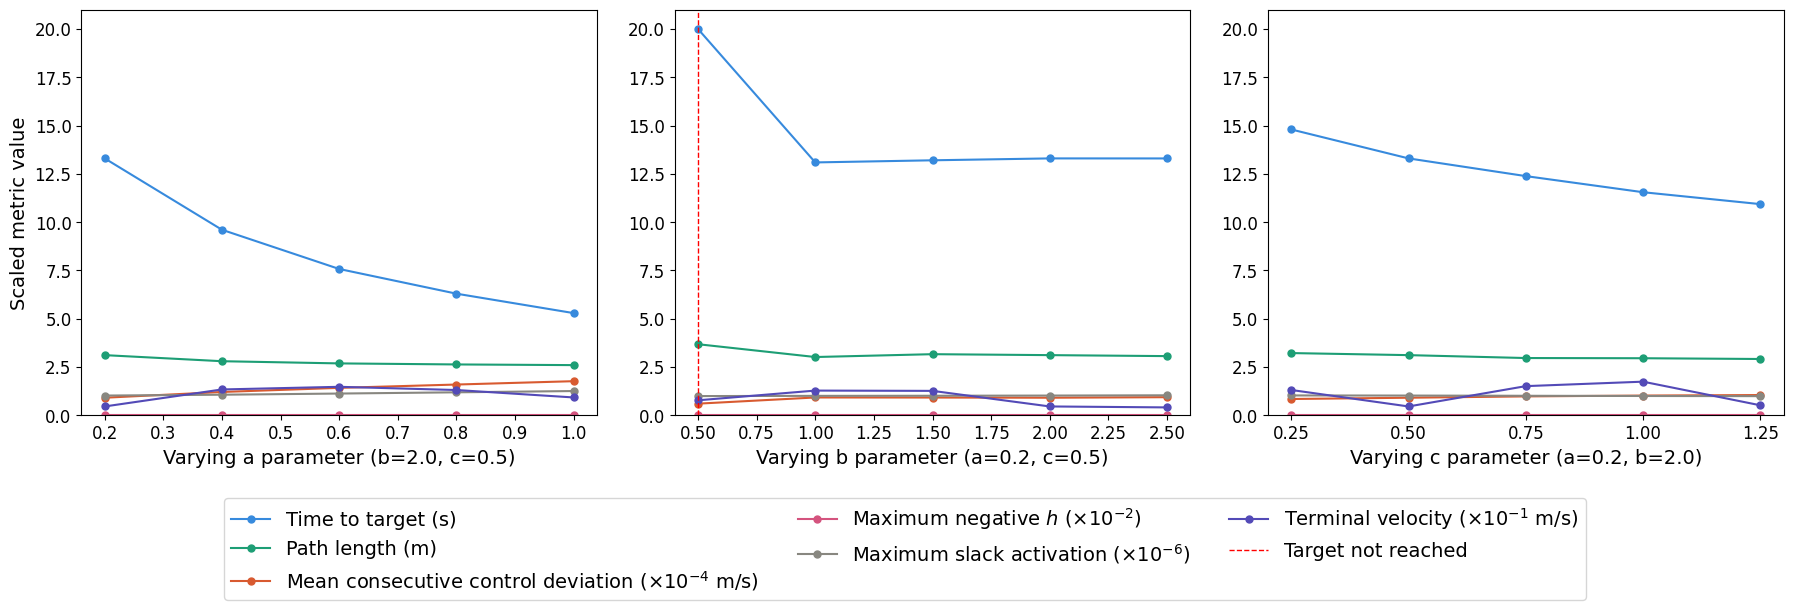

In [20]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({
    "font.size": 14,          # base size
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 14,
})
a_values = [0.2, 0.4, 0.6, 0.8, 1.0]
b_values = [0.5, 1.0, 1.5, 2.0, 2.5]
c_values = [0.25, 0.5, 0.75, 1.0, 1.25]

# scale factors to bring all metrics into similar range
scales = [1, 1, 10000, 100, 1e6, 10]
metric_labels = [
    'Time to target (s)',
    'Path length (m)',
    r'Mean consecutive control deviation (×10$^{-4}$ m/s)',
    r'Maximum negative $h$ (×$10^{-2}$)',
    r'Maximum slack activation (×$10^{-6}$)',
    r'Terminal velocity (×$10^{-1}$ m/s)'
]
colors = ['#378ADD', '#1D9E75', '#D85A30', '#D4537E', '#888780', '#534AB7']

fig, (ax1, ax2, ax3) = plt.subplots(1,3,figsize=(18, 5))
for i, (label, color, scale) in enumerate(zip(metric_labels, colors, scales)):
    ax1.plot(a_values, parameters_a[:, i] * scale, color=color, marker='o',
            linewidth=1.5, markersize=5, label=label)
# ax1.axvline(x=0.2, color='gray', linestyle='--', linewidth=1, label='Baseline')
for i, (label, color, scale) in enumerate(zip(metric_labels, colors, scales)):
    ax2.plot(b_values, parameters_b[:, i] * scale, color=color, marker='o',
             linewidth=1.5, markersize=5, label=label)
# ax2.axvline(x=2.0, color='gray', linestyle='--', linewidth=1, label='Baseline')
ax2.axvline(x=0.5, color='red', linestyle='--', linewidth=1, label='Target not reached')
for i, (label, color, scale) in enumerate(zip(metric_labels, colors, scales)):
    ax3.plot(c_values, parameters_c[:, i] * scale, color=color, marker='o',
             linewidth=1.5, markersize=5, label=label)
# ax3.axvline(x=0.5, color='gray', linestyle='--', linewidth=1, label='Baseline')
ax3.set_xticks(c_values)

ax1.set_xlabel('Varying a parameter (b=2.0, c=0.5)')
ax2.set_xlabel('Varying b parameter (a=0.2, c=0.5)')
ax3.set_xlabel('Varying c parameter (a=0.2, b=2.0)')
ax1.set_ylabel('Scaled metric value')
# ax2.set_ylabel('Scaled metric value')
# ax3.set_ylabel('Scaled metric value')
handles, labels = ax2.get_legend_handles_labels()
fig.legend(handles, labels,
          loc='upper center',
          bbox_to_anchor=(0.5, 0.0),
          ncol=3)  # number of columns)
plt.tight_layout()
ax1.set_ylim(0, 21)
ax2.set_ylim(0, 21)
ax3.set_ylim(0, 21)
plt.subplots_adjust(wspace=0.15)
plt.show()

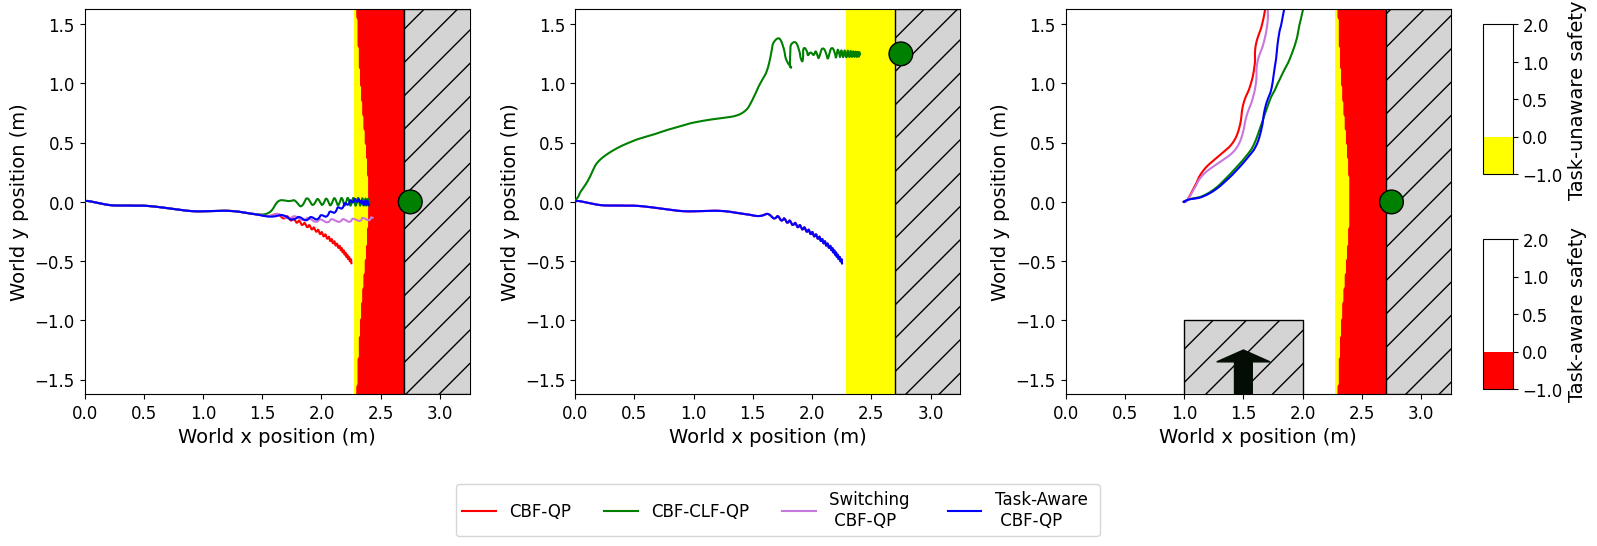

In [21]:
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle, Circle, Arrow

fig, (ax1, ax2, ax3) = plt.subplots(1,3,figsize=(20, 5))

plt.rcParams.update({
    "font.size": 14,          # base size
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
})

# Define thresholds and corresponding colors for task-unaware
bounds2 = [-1, 0, 0.5, 1, 2.0]
colors2 = ['yellow', 'none', 'none', 'none']
cmap2 = mcolors.ListedColormap(colors2)
norm2 = mcolors.BoundaryNorm(bounds2, cmap2.N)
# Define thresholds and corresponding colors for task-aware
bounds = [-1, 0, 0.5, 1, 2.0]
colors = ['red', 'none', 'none', 'none']
cmap = mcolors.ListedColormap(colors)
norm = mcolors.BoundaryNorm(bounds, cmap.N)

safety_map_task = np.load("./safety_map_comp.npy")
safety_map_taskless = np.load("./safety_map_obs.npy")

composite = np.load("./composite_CBF/composite_pos_scenario1.npy")
separated = np.load("./CBF-CLF/separated_pos_scenario1.npy")
base = np.load("./base_CBF/base_pos_scenario1.npy")
switching = np.load("./switching_CBF/switching_pos.npy")

rect = Rectangle((2.7, -1.625), width=0.6, height=3.25, 
                 edgecolor='black', facecolor=(0.83, 0.83, 0.83), hatch="/", zorder=3)
circle_target = Circle((2.75, 0.0), radius=0.1, edgecolor="black", facecolor="green", zorder=3)
ax1.add_patch(rect)
ax1.add_patch(circle_target)

ax1.plot(base[:,0], base[:,1], color="r", label="CBF-QP", zorder=3)
ax1.plot(separated[:,0], separated[:,1], color="g", label="CBF-CLF-QP",zorder=3)
ax1.plot(switching[:,0], switching[:,1], color="#c977dd", label="Switching \n CBF-QP", zorder=3)
ax1.plot(composite[:,0], composite[:,1], color="b", label="Task-Aware \n CBF-QP", zorder=3)

task_safety_plot = ax1.scatter(
    safety_map_task[:, 0],  # x
    safety_map_task[:, 1],  # y
    c=safety_map_task[:, 2],  # h value = color
    cmap=cmap,
    norm=norm,
    s=10,  # dot size
    zorder=2
)

taskless_safety_plot = ax1.scatter(
    safety_map_taskless[:, 0],  # x
    safety_map_taskless[:, 1],  # y
    c=safety_map_taskless[:, 2],  # h value = color
    cmap=cmap2,
    norm=norm2,
    s=10, # dot size
    zorder=1
)

fig.subplots_adjust(right=0.82)

cbar_ax1 = fig.add_axes([0.83, 0.55, 0.015, 0.3])
cbar_ax2 = fig.add_axes([0.83, 0.12, 0.015, 0.3])
fig.colorbar(taskless_safety_plot, cax=cbar_ax1, label='Task-unaware safety')
fig.colorbar(task_safety_plot, cax=cbar_ax2, label='Task-aware safety')

ax1.set_xlim(0.0, 3.25)
ax1.set_ylim(-1.625, 1.625)
ax1.set_xlabel('World x position (m)')
ax1.set_ylabel('World y position (m)')
ax1.add_patch(rect)
ax1.add_patch(circle_target)
ax1.set_aspect('equal')


# Scenario 2

composite = np.load("./composite_CBF/composite_pos_scenario2.npy")
separated = np.load("./CBF-CLF/separated_pos_scenario2.npy")
base = np.load("./base_CBF/base_pos_scenario2.npy")
switching = np.load("./switching_CBF/switching_pos_scenario2.npy")

rect = Rectangle((2.7, -1.625), width=0.6, height=3.25, 
                 edgecolor='black', facecolor=(0.83, 0.83, 0.83), hatch="/", zorder=3)
circle_target = Circle((2.75, 1.25), radius=0.1, edgecolor="black", facecolor="green", zorder=3)
ax2.add_patch(rect)
ax2.add_patch(circle_target)

ax2.plot(base[:,0], base[:,1], color="r", label="CBF-QP")
ax2.plot(separated[:,0], separated[:,1], color="g", label="CBF-CLF-QP", zorder=3)
ax2.plot(switching[:,0], switching[:,1], color="#c977dd", label="Switching CBF-QP", zorder=3)
ax2.plot(composite[:,0], composite[:,1], color="b", label="Task-Aware CBF-QP", zorder=3)
ax2.set_xlim(0.0, 3.25)
ax2.set_ylim(-1.625, 1.625)
ax2.set_aspect('equal')
plt.grid(False)
ax2.set_xlabel("World x position (m)")
ax2.set_ylabel("World y position (m)")

safety_map_task2 = np.load("./safety_map_comp_2.npy")
safety_map_taskless2 = np.load("./safety_map_obs_2.npy")
# task_safety_plot2 = ax2.scatter(
#     safety_map_task2[:, 0],  # x
#     safety_map_task2[:, 1],  # y
#     c=safety_map_task2[:, 2],  # h value = color
#     cmap=cmap,
#     norm=norm,
#     s=10,  # dot size
#     zorder=2
# )

taskless_safety_plot2 = ax2.scatter(
    safety_map_taskless2[:, 0],  # x
    safety_map_taskless2[:, 1],  # y
    c=safety_map_taskless2[:, 2],  # h value = color
    cmap=cmap2,
    norm=norm2,
    s=10, # dot size
    zorder=1
)

# Scenario 3

composite = np.load("./composite_CBF/composite_pos_scenario3.npy")
separated = np.load("./CBF-CLF/separated_pos_scenario3.npy")
base = np.load("./base_CBF/base_pos_scenario3.npy")
switching = np.load("./switching_CBF/switching_pos_scenario3.npy")

rect_obs = Rectangle((2.7, -1.625), width=0.6, height=3.25, 
                 edgecolor='black', facecolor=(0.83, 0.83, 0.83), hatch="/", zorder=3)
rect_moving = Rectangle((1, -2), width=1, height=1, 
                 edgecolor='black', facecolor=(0.83, 0.83, 0.83), hatch="/", zorder=3)
circle_target = Circle((2.75, 0), radius=0.1, edgecolor="black", facecolor="green", zorder=3)
arrow = Arrow(1.5, -1.75, 0, 0.5, width=0.75, color=(0.01, 0.05, 0.01), zorder=4)
ax3.add_patch(rect_obs)
ax3.add_patch(rect_moving)
ax3.add_patch(circle_target)
ax3.add_patch(arrow)

ax3.plot(base[:,0], base[:,1], color="r", label="CBF-QP")
ax3.plot(separated[:,0], separated[:,1], color="g", label="CBF-CLF-QP")
ax3.plot(switching[:,0], switching[:,1], color="#c977dd", label="Switching CBF-QP")
ax3.plot(composite[:,0], composite[:,1], color="b", label="Task-Aware CBF-QP")
ax3.set_xlim(0.0, 3.25)
ax3.set_ylim(-1.625, 1.625)
ax3.set_aspect('equal')
plt.grid(False)
ax3.set_xlabel("World x position (m)")
ax3.set_ylabel("World y position (m)")

task_safety_plot = ax3.scatter(
    safety_map_task[:, 0],  # x
    safety_map_task[:, 1],  # y
    c=safety_map_task[:, 2],  # h value = color
    cmap=cmap,
    norm=norm,
    s=10,  # dot size
    zorder=2
)

taskless_safety_plot = ax3.scatter(
    safety_map_taskless[:, 0],  # x
    safety_map_taskless[:, 1],  # y
    c=safety_map_taskless[:, 2],  # h value = color
    cmap=cmap2,
    norm=norm2,
    s=10, # dot size
    zorder=1
)

handles, labels = ax1.get_legend_handles_labels()
order = [0,1,2,3]
ax1.legend([handles[i] for i in order], [labels[i] for i in order],
          loc='center',
          bbox_to_anchor=(1.8, -0.3),
          ncol=4)  # number of columns)

plt.show()

In [38]:
import numpy as np

# Path length
def path_length(points):
    diffs = np.diff(points, axis=0)      # (N-1, d)
    segment_lengths = np.linalg.norm(diffs, axis=1)
    return np.sum(segment_lengths)

# Time to target
def path_time(points):
    time = points.shape[0] * 0.002
    return time

# Consecutive control deviation
def consecutive_change(cmd_array):
    change = []
    for i in range(np.size(cmd_array,axis=0)):
        if i != 0:
            prev_cmd = cmd_array[i-1]
            curr_cmd = cmd_array[i]
            change.append(np.sum((curr_cmd - prev_cmd)**2))
        else:
            change.append(0)
    change = np.array(change)
    return np.mean(change)

def val_extraction(vals):
    # Penetration depth
    penetration = np.max(-np.min(vals[0:,0]), 0)
    # Slack activation
    slack = np.max(vals[0:,-2])
    # Terminal velocity
    terminal_vel = vals[-1,-1]

    return [penetration, slack, terminal_vel]

def val_extraction3(vals):
    # Penetration depth
    penetration_static = np.max(-np.min(vals[0:,0]), 0)
    penetration_moving = np.max(-np.min(vals[0:,2]), 0)
    penetration = np.max((penetration_moving, penetration_static))
    # Slack activation
    slack_static = np.max(vals[0:,-2])
    slack_moving = np.max(vals[0:,-3])
    slack = np.max((slack_static, slack_moving))
    # Terminal velocity
    terminal_vel = vals[-1,-1]

    return [penetration, slack, terminal_vel]

def parameter_curve3(points, cmds, vals):
    # print("Time to Target:", path_time(points))
    # print("Path Length:", path_length(points))
    # print("Consecutive Control Deviation", consecutive_change(cmds))
    # print("Penetration Depth:", val_extraction(vals)[0])
    # print("Max Slack:", val_extraction(vals)[1])
    # print("Terminal Velocity:", val_extraction(vals)[2])
    return [path_time(points), path_length(points), consecutive_change(cmds), 
            val_extraction3(vals)[0], val_extraction3(vals)[1], val_extraction3(vals)[2]]

def parameter_curve(points, cmds, vals):
    # print("Time to Target:", path_time(points))
    # print("Path Length:", path_length(points))
    # print("Consecutive Control Deviation", consecutive_change(cmds))
    # print("Penetration Depth:", val_extraction(vals)[0])
    # print("Max Slack:", val_extraction(vals)[1])
    # print("Terminal Velocity:", val_extraction(vals)[2])
    return [path_time(points), path_length(points), consecutive_change(cmds), 
            val_extraction(vals)[0], val_extraction(vals)[1], val_extraction(vals)[2]]

In [39]:
# Scenario 1

points_base = np.load("./base_CBF/base_pos_scenario1.npy")
cmds_base = np.load("./base_CBF/base_cmds_scenario1.npy")
vals_base = np.load("./base_CBF/base_vals_scenario1.npy")
points_separated = np.load("./CBF-CLF/separated_pos_scenario1.npy")
cmds_separated = np.load("./CBF-CLF/separated_cmds_scenario1.npy")
vals_separated = np.load("./CBF-CLF/separated_vals_scenario1.npy")
points_switching = np.load("./switching_CBF/switching_pos_scenario1.npy")
cmds_switching = np.load("./switching_CBF/switching_cmds_scenario1.npy")
vals_switching = np.load("./switching_CBF/switching_vals_scenario1.npy")
points_composite = np.load("./composite_CBF/composite_pos_scenario1.npy")
cmds_composite = np.load("./composite_CBF/composite_cmds_scenario1.npy")
vals_composite = np.load("./composite_CBF/composite_vals_scenario1.npy")

vals_switching = vals_switching[0]
vals_composite = vals_composite[0]
parameters_scenario1 = np.array(parameter_curve(points_base, cmds_base, vals_base))
parameters_scenario1 = np.vstack((parameters_scenario1, parameter_curve(points_separated, cmds_separated, vals_separated)))
parameters_scenario1 = np.vstack((parameters_scenario1, parameter_curve(points_switching, cmds_switching, vals_switching)))
parameters_scenario1 = np.vstack((parameters_scenario1, parameter_curve(points_composite, cmds_composite, vals_composite)))
print(parameters_scenario1)

parameters_scenario1[0,0:2] = np.zeros(2)
parameters_scenario1[0,-1] = 0

[[ 1.89040000e+01  3.21151223e+00  8.57913669e-05 -4.92725214e-02
   1.01013299e-06  6.38006502e-02]
 [ 1.27060000e+01  5.34626597e+00  3.13111916e-04  9.92373810e-02
   1.14244884e-05  2.11575989e-01]
 [ 6.68600000e+00  3.54635714e+00  3.07621298e-02  7.80165849e-02
   2.66560760e-02  1.77158780e-01]
 [ 1.33020000e+01  3.11934845e+00  9.14900015e-05 -2.14580478e-02
   1.02682362e-06  4.63143946e-02]]


In [40]:
# Scenario 2

points_base = np.load("./base_CBF/base_pos_scenario2.npy")
cmds_base = np.load("./base_CBF/base_cmds_scenario2.npy")
vals_base = np.load("./base_CBF/base_vals_scenario2.npy")
points_separated = np.load("./CBF-CLF/separated_pos_scenario2.npy")
cmds_separated = np.load("./CBF-CLF/separated_cmds_scenario2.npy")
vals_separated = np.load("./CBF-CLF/separated_vals_scenario2.npy")
points_switching = np.load("./switching_CBF/switching_pos_scenario2.npy")
cmds_switching = np.load("./switching_CBF/switching_cmds_scenario2.npy")
vals_switching = np.load("./switching_CBF/switching_vals_scenario2.npy")
points_composite = np.load("./composite_CBF/composite_pos_scenario2.npy")
cmds_composite = np.load("./composite_CBF/composite_cmds_scenario2.npy")
vals_composite = np.load("./composite_CBF/composite_vals_scenario2.npy")

vals_switching = vals_switching[0]
vals_composite = vals_composite[0]
parameters_scenario2 = np.array(parameter_curve(points_base, cmds_base, vals_base))
parameters_scenario2 = np.vstack((parameters_scenario2, parameter_curve(points_separated, cmds_separated, vals_separated)))
parameters_scenario2 = np.vstack((parameters_scenario2, parameter_curve(points_switching, cmds_switching, vals_switching)))
parameters_scenario2 = np.vstack((parameters_scenario2, parameter_curve(points_composite, cmds_composite, vals_composite)))
print(parameters_scenario2)

parameters_scenario2[0, :2] = np.zeros(2)
parameters_scenario2[2:, :2] = np.zeros((2,2))
parameters_scenario2[0, -1] = 0
parameters_scenario2[-2:, -1] = np.zeros(2)

[[ 1.89040000e+01  3.21151223e+00  8.57913669e-05 -4.92725214e-02
   1.01013299e-06  6.38006502e-02]
 [ 1.63460000e+01  7.74586292e+00  2.64538113e-03  9.81332142e-02
   7.73510444e-05  1.63455858e-01]
 [ 1.89040000e+01  3.21151223e+00  8.57913669e-05 -4.92725214e-02
   1.00996688e-06  6.38006502e-02]
 [ 1.89040000e+01  3.21151223e+00  8.57913669e-05 -4.92725214e-02
   1.00996688e-06  6.38006502e-02]]


In [62]:
# Scenario 3

points_base = np.load("./base_CBF/base_pos_scenario3.npy")
cmds_base = np.load("./base_CBF/base_cmds_scenario3.npy")
vals_base = np.load("./base_CBF/base_vals_scenario3.npy")
points_separated = np.load("./CBF-CLF/separated_pos_scenario3.npy")
cmds_separated = np.load("./CBF-CLF/separated_cmds_scenario3.npy")
vals_separated = np.load("./CBF-CLF/separated_vals_scenario3.npy")
points_switching = np.load("./switching_CBF/switching_pos_scenario3.npy")
cmds_switching = np.load("./switching_CBF/switching_cmds_scenario3.npy")
vals_switching = np.load("./switching_CBF/switching_vals_scenario3.npy")
points_composite = np.load("./composite_CBF/composite_pos_scenario3.npy")
cmds_composite = np.load("./composite_CBF/composite_cmds_scenario3.npy")
vals_composite = np.load("./composite_CBF/composite_vals_scenario3.npy")

vals_switching = vals_switching[0]
vals_composite = vals_composite[0]
parameters_scenario3 = np.array(parameter_curve3(points_base, cmds_base, vals_base))
parameters_scenario3 = np.vstack((parameters_scenario3, parameter_curve3(points_separated, cmds_separated, vals_separated)))
parameters_scenario3 = np.vstack((parameters_scenario3, parameter_curve3(points_switching, cmds_switching, vals_switching)))
parameters_scenario3 = np.vstack((parameters_scenario3, parameter_curve3(points_composite, cmds_composite, vals_composite)))
print(parameters_scenario3)

parameters_scenario3[0:, :2] = np.zeros((4,2))
parameters_scenario3[0:, -1] = np.zeros(4)

[[ 5.00000000e+00  3.61949390e+00  5.90840000e-04 -1.74489087e-01
   1.20017772e-06  8.87318917e-01]
 [ 5.00000000e+00  4.17121240e+00  6.76440000e-04 -3.02279404e-01
   1.46850502e-05  5.36449869e-01]
 [ 5.00000000e+00  3.61949390e+00  5.90840000e-04 -1.74489087e-01
   1.20017772e-06  8.87318917e-01]
 [ 5.00000000e+00  3.66164087e+00  5.07160000e-04 -2.21020677e-01
   3.96210370e-06  7.56717369e-01]]


In [42]:
def annotate_bars_right(ax, data, scales, offsets, ylim_max):
    for i, scale in enumerate(scales):
        for j in range(data.shape[0]):
            val = data[j, i] * scale
            x = j + offsets[i]
            if val > ylim_max:
                ax.text(x+0.35, ylim_max - 0.3, f'↑{val:.2f}',
                        ha='center', va='top', fontsize=14, color='black')

ylim_max = 21

In [43]:
def annotate_bars_mix(ax, data, scales, offsets, ylim_max):
    for i, scale in enumerate(scales):
        for j in range(data.shape[0]):
            val = data[j, i] * scale
            x = j + offsets[i]
            if val > ylim_max and i < 3:
                ax.text(x-0.4, ylim_max - 0.3, f'{val:.2f}↑',
                        ha='center', va='top', fontsize=14, color='black')
            elif val > ylim_max and i >= 3:
                ax.text(x+0.45, ylim_max - 0.3, f'↑{val:.2f}',
                        ha='center', va='top', fontsize=14, color='black')

ylim_max = 21

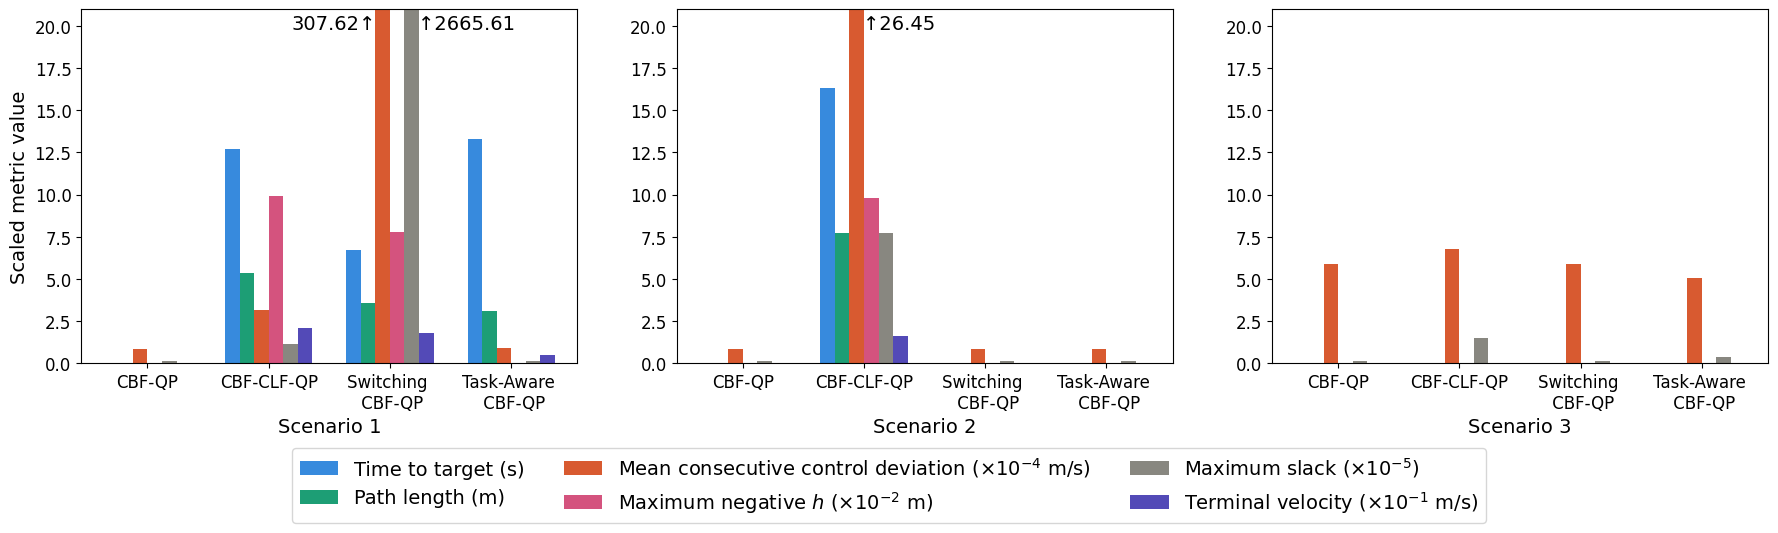

In [63]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({
    "font.size": 14,          # base size
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 14,
})

a_values = [0.2, 0.4, 0.6, 0.8]
b_values = [0.5, 1.0, 1.5, 2.0]
c_values = [0.25, 0.5, 0.75, 1.0]

scales = [1, 1, 10000, 1e2, 1e5, 10]
metric_labels = [
    'Time to target (s)',
    'Path length (m)',
    r'Mean consecutive control deviation (×$10^{-4}$ m/s)',
    r'Maximum negative $h$ (×$10^{-2}$ m)',
    r'Maximum slack (×$10^{-5}$)',
    r'Terminal velocity (×$10^{-1}$ m/s)'
]
colors = ['#378ADD', '#1D9E75', '#D85A30', '#D4537E', '#888780', '#534AB7']
word_labels = ['CBF-QP', 'CBF-CLF-QP', 'Switching \n CBF-QP', 'Task-Aware \n CBF-QP']

n_metrics = len(metric_labels)
n_vals = len(a_values)
width = 0.12
offsets = np.linspace(-(n_metrics-1)*width/2, (n_metrics-1)*width/2, n_metrics)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

for i, (label, color, scale) in enumerate(zip(metric_labels, colors, scales)):
    ax1.bar(np.arange(n_vals) + offsets[i], parameters_scenario1[:, i] * scale,
            width=width, color=color, label=label)
ax1.set_xticks(range(n_vals))
ax1.set_xticklabels(word_labels)
ax1.set_xlabel('Scenario 1')
ax1.set_ylabel('Scaled metric value')
ax1.set_ylim(0, 21)

# i, j = 2, 2  # metric index, method index
# val = parameters_scenario1[j, i] * scales[i]
# ax1.text(j + offsets[i], val + 0.2, f'{val:.2f}',
#          ha='center', va='bottom', fontsize=8, color='black')

for i, (label, color, scale) in enumerate(zip(metric_labels, colors, scales)):
    ax2.bar(np.arange(n_vals) + offsets[i], parameters_scenario2[:, i] * scale,
            width=width, color=color, label=label)
ax2.set_xticks(range(n_vals))
ax2.set_xticklabels(word_labels)
ax2.set_xlabel('Scenario 2')
# ax2.set_ylabel('Scaled metric value')
ax2.set_ylim(0, 21)

for i, (label, color, scale) in enumerate(zip(metric_labels, colors, scales)):
    ax3.bar(np.arange(n_vals) + offsets[i], parameters_scenario3[:, i] * scale,
            width=width, color=color, label=label)
ax3.set_xticks(range(n_vals))
ax3.set_xticklabels(word_labels)
ax3.set_xlabel('Scenario 3')
# ax3.set_ylabel('Scaled metric value')
ax3.set_ylim(0, 21)

annotate_bars_mix(ax1, parameters_scenario1, scales, offsets, ylim_max)
annotate_bars_right(ax2, parameters_scenario2, scales, offsets, ylim_max)
annotate_bars_mix(ax3, parameters_scenario3, scales, offsets, ylim_max)

handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels,
           loc='upper center',
           bbox_to_anchor=(0.5, 0.10),
           ncol=3)
plt.tight_layout()
plt.subplots_adjust(wspace=0.2, bottom=0.25)
plt.show()

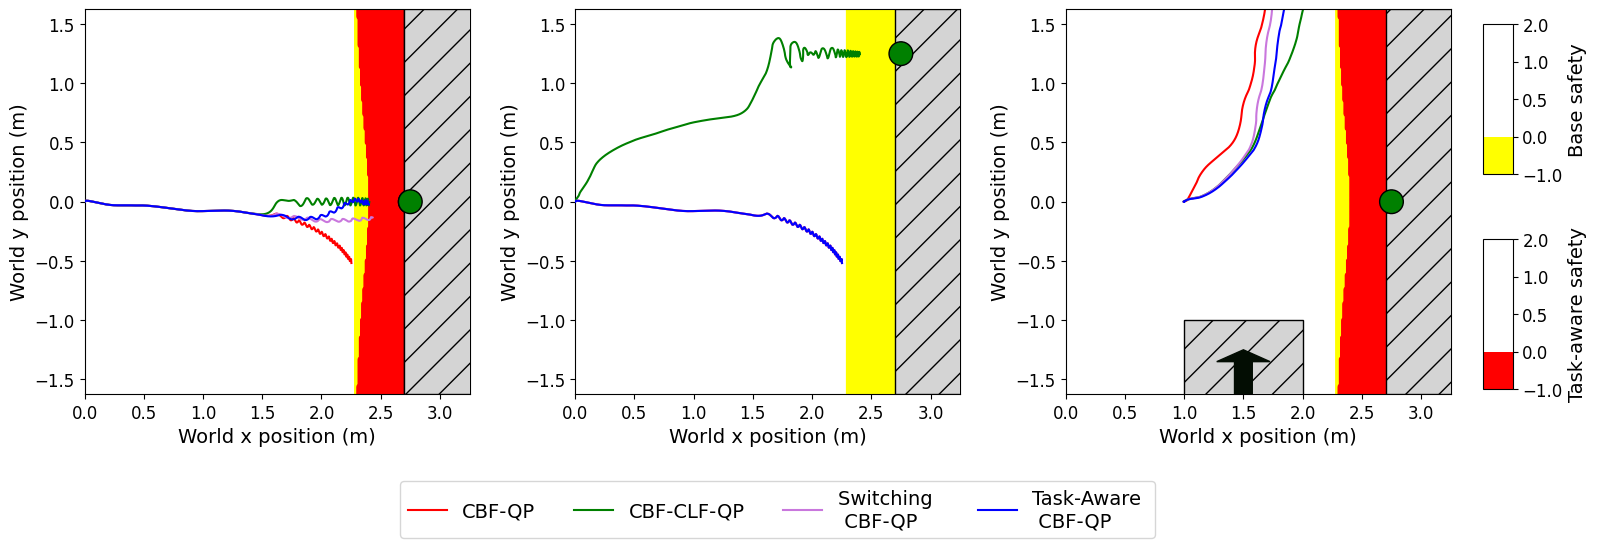

In [45]:
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle, Circle, Arrow

fig, (ax1, ax2, ax3) = plt.subplots(1,3,figsize=(20, 5))

plt.rcParams.update({
    "font.size": 14,          # base size
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 14,
})

# Define thresholds and corresponding colors for task-unaware
bounds2 = [-1, 0, 0.5, 1, 2.0]
colors2 = ['yellow', 'none', 'none', 'none']
cmap2 = mcolors.ListedColormap(colors2)
norm2 = mcolors.BoundaryNorm(bounds2, cmap2.N)
# Define thresholds and corresponding colors for task-aware
bounds = [-1, 0, 0.5, 1, 2.0]
colors = ['red', 'none', 'none', 'none']
cmap = mcolors.ListedColormap(colors)
norm = mcolors.BoundaryNorm(bounds, cmap.N)

safety_map_task = np.load("./safety_map_comp.npy")
safety_map_taskless = np.load("./safety_map_obs.npy")

composite = np.load("./composite_CBF/composite_pos_scenario1.npy")
separated = np.load("./CBF-CLF/separated_pos_scenario1.npy")
base = np.load("./base_CBF/base_pos_scenario1.npy")
switching = np.load("./switching_CBF/switching_pos.npy")

rect = Rectangle((2.7, -1.625), width=0.6, height=3.25, 
                 edgecolor='black', facecolor=(0.83, 0.83, 0.83), hatch="/", zorder=3)
circle_target = Circle((2.75, 0.0), radius=0.1, edgecolor="black", facecolor="green", zorder=3)
ax1.add_patch(rect)
ax1.add_patch(circle_target)

ax1.plot(base[:,0], base[:,1], color="r", label="CBF-QP", zorder=3)
ax1.plot(separated[:,0], separated[:,1], color="g", label="CBF-CLF-QP",zorder=3)
ax1.plot(switching[:,0], switching[:,1], color="#c977dd", label="Switching \n CBF-QP", zorder=3)
ax1.plot(composite[:,0], composite[:,1], color="b", label="Task-Aware \n CBF-QP", zorder=3)

task_safety_plot = ax1.scatter(
    safety_map_task[:, 0],  # x
    safety_map_task[:, 1],  # y
    c=safety_map_task[:, 2],  # h value = color
    cmap=cmap,
    norm=norm,
    s=10,  # dot size
    zorder=2
)

taskless_safety_plot = ax1.scatter(
    safety_map_taskless[:, 0],  # x
    safety_map_taskless[:, 1],  # y
    c=safety_map_taskless[:, 2],  # h value = color
    cmap=cmap2,
    norm=norm2,
    s=10, # dot size
    zorder=1
)

fig.subplots_adjust(right=0.82)

cbar_ax1 = fig.add_axes([0.83, 0.55, 0.015, 0.3])
cbar_ax2 = fig.add_axes([0.83, 0.12, 0.015, 0.3])
fig.colorbar(taskless_safety_plot, cax=cbar_ax1, label='Base safety')
fig.colorbar(task_safety_plot, cax=cbar_ax2, label='Task-aware safety')

ax1.set_xlim(0.0, 3.25)
ax1.set_ylim(-1.625, 1.625)
ax1.set_xlabel('World x position (m)')
ax1.set_ylabel('World y position (m)')
ax1.add_patch(rect)
ax1.add_patch(circle_target)
ax1.set_aspect('equal')


# Scenario 2

composite = np.load("./composite_CBF/composite_pos_scenario2.npy")
separated = np.load("./CBF-CLF/separated_pos_scenario2.npy")
base = np.load("./base_CBF/base_pos_scenario2.npy")
switching = np.load("./switching_CBF/switching_pos_scenario2.npy")

rect = Rectangle((2.7, -1.625), width=0.6, height=3.25, 
                 edgecolor='black', facecolor=(0.83, 0.83, 0.83), hatch="/", zorder=3)
circle_target = Circle((2.75, 1.25), radius=0.1, edgecolor="black", facecolor="green", zorder=3)
ax2.add_patch(rect)
ax2.add_patch(circle_target)

ax2.plot(base[:,0], base[:,1], color="r", label="CBF-QP")
ax2.plot(separated[:,0], separated[:,1], color="g", label="CBF-CLF-QP", zorder=3)
ax2.plot(switching[:,0], switching[:,1], color="#c977dd", label="Switching CBF-QP", zorder=3)
ax2.plot(composite[:,0], composite[:,1], color="b", label="Task-Aware CBF-QP", zorder=3)
ax2.set_xlim(0.0, 3.25)
ax2.set_ylim(-1.625, 1.625)
ax2.set_aspect('equal')
plt.grid(False)
ax2.set_xlabel("World x position (m)")
ax2.set_ylabel("World y position (m)")

safety_map_task2 = np.load("./safety_map_comp_2.npy")
safety_map_taskless2 = np.load("./safety_map_obs_2.npy")
# task_safety_plot2 = ax2.scatter(
#     safety_map_task2[:, 0],  # x
#     safety_map_task2[:, 1],  # y
#     c=safety_map_task2[:, 2],  # h value = color
#     cmap=cmap,
#     norm=norm,
#     s=10,  # dot size
#     zorder=2
# )

taskless_safety_plot2 = ax2.scatter(
    safety_map_taskless2[:, 0],  # x
    safety_map_taskless2[:, 1],  # y
    c=safety_map_taskless2[:, 2],  # h value = color
    cmap=cmap2,
    norm=norm2,
    s=10, # dot size
    zorder=1
)

# Scenario 3

composite = np.load("./composite_CBF/composite_pos_scenario3.npy")
separated = np.load("./CBF-CLF/separated_pos_scenario3.npy")
base = np.load("./base_CBF/base_pos_scenario3.npy")
switching = np.load("./switching_CBF/switching_pos_scenario3.npy")

rect_obs = Rectangle((2.7, -1.625), width=0.6, height=3.25, 
                 edgecolor='black', facecolor=(0.83, 0.83, 0.83), hatch="/", zorder=3)
rect_moving = Rectangle((1, -2), width=1, height=1, 
                 edgecolor='black', facecolor=(0.83, 0.83, 0.83), hatch="/", zorder=3)
circle_target = Circle((2.75, 0), radius=0.1, edgecolor="black", facecolor="green", zorder=3)
arrow = Arrow(1.5, -1.75, 0, 0.5, width=0.75, color=(0.01, 0.05, 0.01), zorder=4)
ax3.add_patch(rect_obs)
ax3.add_patch(rect_moving)
ax3.add_patch(circle_target)
ax3.add_patch(arrow)

ax3.plot(base[:,0], base[:,1], color="r", label="CBF-QP")
ax3.plot(separated[:,0], separated[:,1], color="g", label="CBF-CLF-QP")
ax3.plot(switching[:,0], switching[:,1], color="#c977dd", label="Switching CBF-QP")
ax3.plot(composite[:,0], composite[:,1], color="b", label="Task-Aware CBF-QP")
ax3.set_xlim(0.0, 3.25)
ax3.set_ylim(-1.625, 1.625)
ax3.set_aspect('equal')
plt.grid(False)
ax3.set_xlabel("World x position (m)")
ax3.set_ylabel("World y position (m)")

task_safety_plot = ax3.scatter(
    safety_map_task[:, 0],  # x
    safety_map_task[:, 1],  # y
    c=safety_map_task[:, 2],  # h value = color
    cmap=cmap,
    norm=norm,
    s=10,  # dot size
    zorder=2
)

taskless_safety_plot = ax3.scatter(
    safety_map_taskless[:, 0],  # x
    safety_map_taskless[:, 1],  # y
    c=safety_map_taskless[:, 2],  # h value = color
    cmap=cmap2,
    norm=norm2,
    s=10, # dot size
    zorder=1
)

handles, labels = ax1.get_legend_handles_labels()
order = [0,1,2,3]
ax1.legend([handles[i] for i in order], [labels[i] for i in order],
          loc='center',
          bbox_to_anchor=(1.8, -0.3),
          ncol=4)  # number of columns)

plt.show()